# Pneumonia Detection CNN Model

This notebook trains a CNN to classify chest X-rays into `NORMAL` vs `PNEUMONIA`.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.13.2


In [3]:
# Configuration
DATASET_ROOT = "dataset"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE

MODEL_PATH = "best_model.keras"

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

print("Dataset paths validated.")

Dataset paths validated.


## 1) Exploratory Data Analysis

In [4]:
def count_images(split_dir):
    counts = {}
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = os.path.join(split_dir, class_name)
        counts[class_name] = len([
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f))
        ])
    return counts

split_counts = {
    "train": count_images(TRAIN_DIR),
    "val": count_images(VAL_DIR),
    "test": count_images(TEST_DIR),
}

for split_name, c in split_counts.items():
    print(f"{split_name.upper()}: NORMAL={c['NORMAL']}, PNEUMONIA={c['PNEUMONIA']}, TOTAL={c['NORMAL'] + c['PNEUMONIA']}")

TRAIN: NORMAL=1341, PNEUMONIA=3875, TOTAL=5216
VAL: NORMAL=8, PNEUMONIA=8, TOTAL=16
TEST: NORMAL=234, PNEUMONIA=390, TOTAL=624


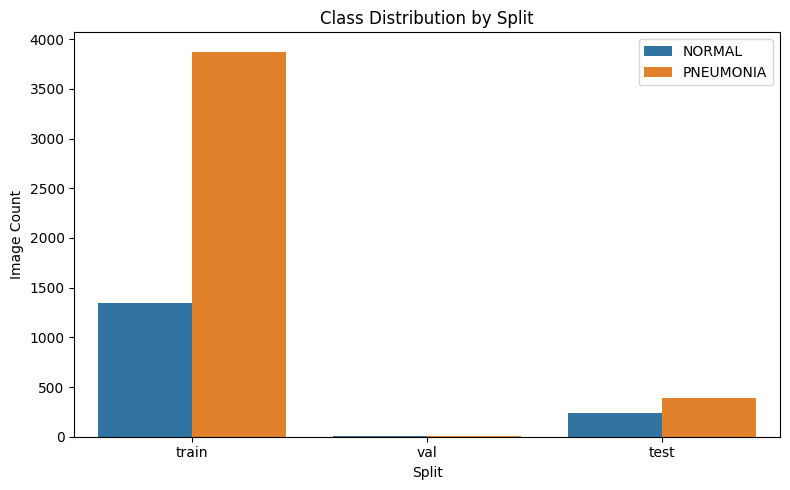

In [5]:
# Class distribution plot
splits = []
classes = []
counts = []

for split_name in ["train", "val", "test"]:
    for class_name in ["NORMAL", "PNEUMONIA"]:
        splits.append(split_name)
        classes.append(class_name)
        counts.append(split_counts[split_name][class_name])

plt.figure(figsize=(8, 5))
sns.barplot(x=splits, y=counts, hue=classes)
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

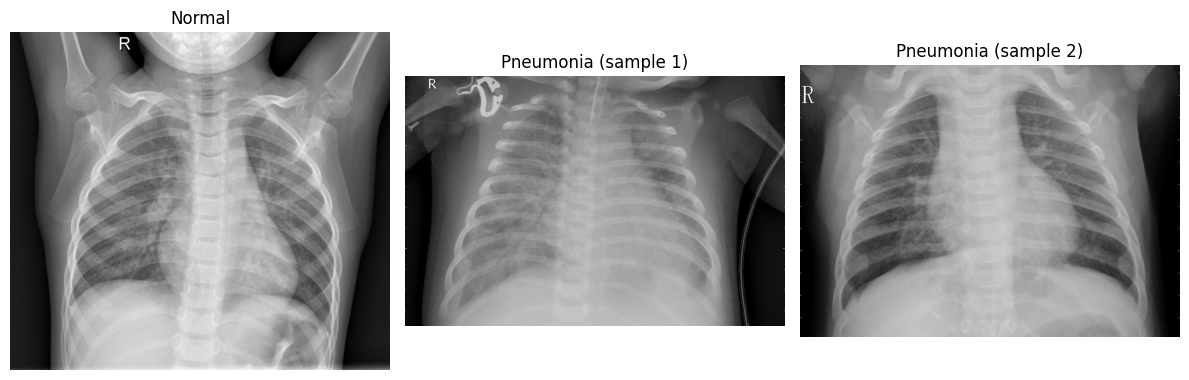

In [6]:
# Visualize sample images from each class in train split
train_normal_dir = os.path.join(TRAIN_DIR, "NORMAL")
train_pneumonia_dir = os.path.join(TRAIN_DIR, "PNEUMONIA")

normal_samples = sorted(os.listdir(train_normal_dir))[:3]
pneumonia_samples = sorted(os.listdir(train_pneumonia_dir))[:3]

sample_paths = [
    os.path.join(train_normal_dir, normal_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[1]),
]

titles = ["Normal", "Pneumonia (sample 1)", "Pneumonia (sample 2)"]

plt.figure(figsize=(12, 4))
for i, (path, title) in enumerate(zip(sample_paths, titles), start=1):
    img = keras.utils.load_img(path, color_mode="grayscale")
    arr = keras.utils.img_to_array(img)
    plt.subplot(1, 3, i)
    plt.imshow(arr.squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Check a few raw image shapes
shape_samples = []
for class_name, class_dir in [("NORMAL", train_normal_dir), ("PNEUMONIA", train_pneumonia_dir)]:
    sample_file = sorted(os.listdir(class_dir))[0]
    sample_path = os.path.join(class_dir, sample_file)
    img = keras.utils.load_img(sample_path)
    shape_samples.append((class_name, sample_file, img.size))  # PIL size = (width, height)

for class_name, file_name, size in shape_samples:
    print(f"{class_name}: {file_name} -> original size (W,H) = {size}")
print(f"Target resize: {IMG_SIZE}")

NORMAL: IM-0115-0001.jpeg -> original size (W,H) = (2090, 1858)
PNEUMONIA: person1000_bacteria_2931.jpeg -> original size (W,H) = (1152, 760)
Target resize: (150, 150)


## 2) Data Loading and Preprocessing

In [8]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']


In [9]:
# Data augmentation layers (active only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# Performance optimization for tf.data pipelines
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")

Datasets are ready.


## 3) CNN Model Architecture

In [10]:
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Preprocessing inside model graph
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255)(x)

# Block 1
x = layers.Conv2D(32, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 4
x = layers.Conv2D(256, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (3, 3), strides=(1, 1), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Classifier
x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="pneumonia_cnn")
model.summary()

Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,16

 Total params: 11,796,001 (45.00 MB)

 Trainable params: 11,793,057 (44.99 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 4) Compile Model and Compute Class Weights

In [ ]:
# Build class-weight dictionary from known train counts
num_normal = split_counts["train"]["NORMAL"]
num_pneumonia = split_counts["train"]["PNEUMONIA"]

labels = np.array([0] * num_normal + [1] * num_pneumonia)
weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
class_weight_dict = {0: float(weights[0]), 1: float(weights[1])}

print("Class weights:", class_weight_dict)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled.")

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}
Model compiled.


: 

## 5) Train the CNN

In [ ]:
my_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=my_callbacks,
)

print(f"Best model checkpoint saved to: {MODEL_PATH}")

Epoch 1/30


## 6) Evaluate and Visualize Results

In [ ]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Load best checkpoint and evaluate on test set
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
# Predictions, confusion matrix, and classification report
y_true_batches = []
y_prob_batches = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())

y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

In [ ]:
# Show sample predictions from test set
sample_images = []
sample_true = []
for images, labels in test_ds.take(1):
    sample_images = images[:9]
    sample_true = labels[:9].numpy().astype(int).ravel()

sample_probs = best_model.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= 0.5).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7) Overfitting Countermeasures Used

1. Data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`).
2. Batch normalization after each convolution block.
3. Dropout in each block (`0.25`) and classifier head (`0.5`).
4. Class weights to counter class imbalance.
5. Early stopping on validation loss.
6. Learning-rate reduction on plateau.